In [ ]:
!unzip archive(4).zip

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `unzip archive(4).zip'


Found dataset zip file: archive (4).zip. Extracting CSV files...
Extraction completed successfully!



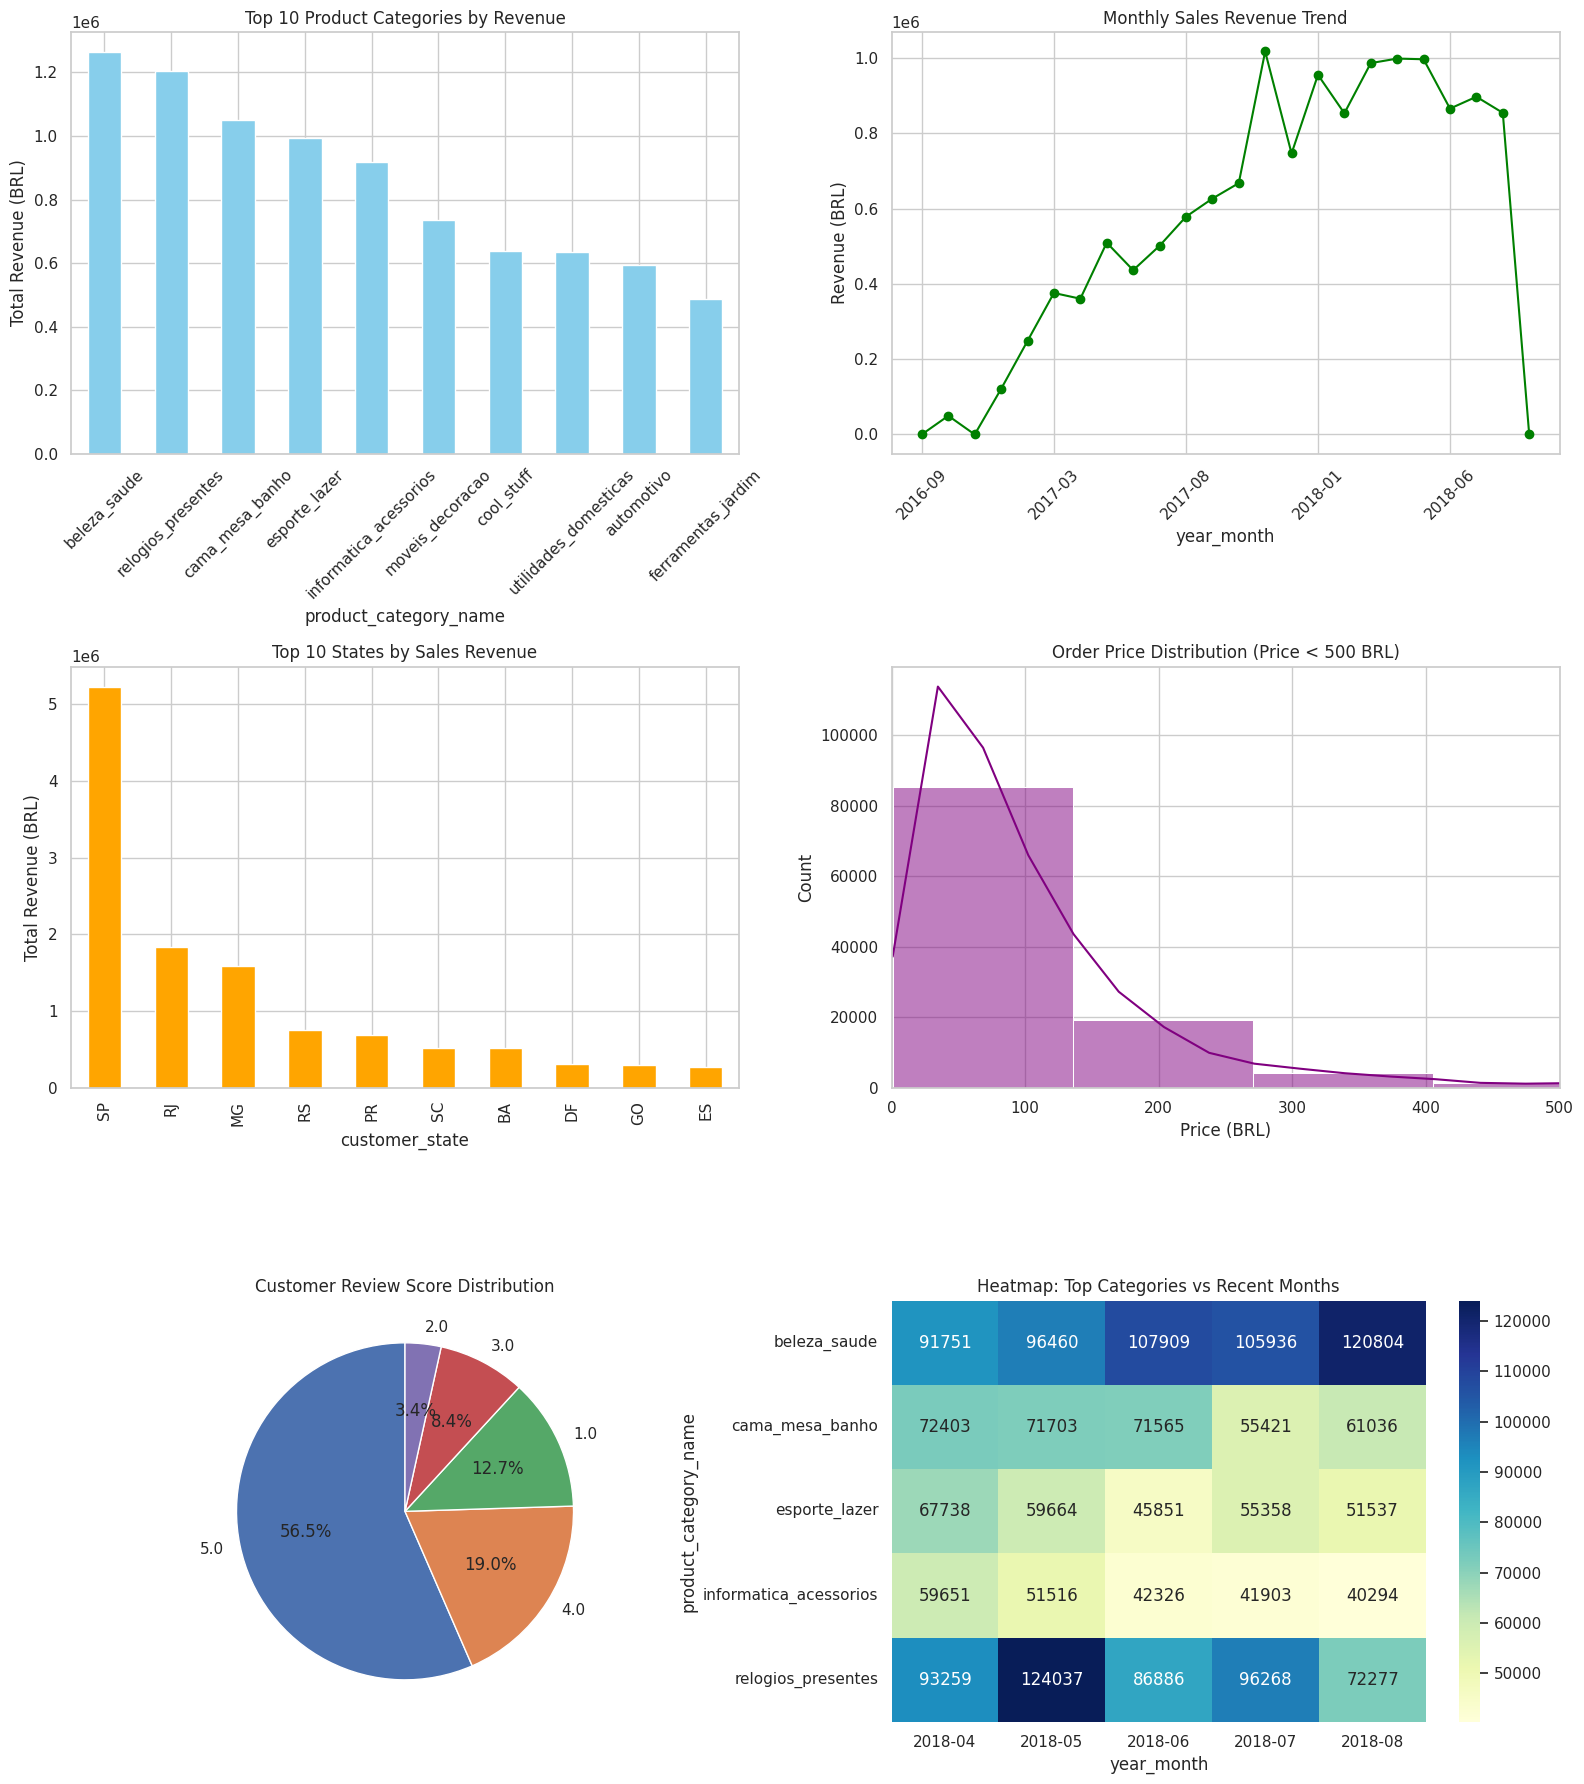


       MANAGEMENT DASHBOARD SUMMARY       
Total Sales Revenue : BRL 13,651,923.47
Total Orders Count  : 98,666
Top Product Category: beleza_saude (BRL 1,263,138.54)
Peak Month          : 2017-11 (BRL 1,017,758.83)


In [ ]:
import zipfile
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1: AUTOMATIC ZIP EXTRACTION
# ==========================================
# Search for any .zip file in the current working directory
zip_files = glob.glob("*.zip")

if zip_files:
    zip_path = zip_files[0]
    print(f"Found dataset zip file: {zip_path}. Extracting CSV files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extraction completed successfully!\n")
else:
    print("No .zip file detected. Assuming CSV files are already extracted in the directory.\n")

# ==========================================
# STEP 2: LOAD DATASETS
# ==========================================
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

# ==========================================
# STEP 3: DATA CLEANING & MERGING
# ==========================================
# Convert timestamps and fill missing product categories
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
products['product_category_name'] = products['product_category_name'].fillna('Unknown')

# Merge relevant tables into a master dataframe
df_merged = items.merge(orders, on='order_id') \
                 .merge(products, on='product_id') \
                 .merge(customers, on='customer_id') \
                 .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# ==========================================
# STEP 4: SALES ANALYSIS (5 QUESTIONS)
# ==========================================
# 1. Top Revenue Category
rev_by_cat = df_merged.groupby('product_category_name')['price'].sum().sort_values(ascending=False)

# 2. Peak Sales Month
monthly_sales = df_merged.groupby('year_month')['price'].sum()

# 3. Best Performing Region (State)
state_sales = df_merged.groupby('customer_state')['price'].sum().sort_values(ascending=False)

# 4. Average Order Value (AOV) Trend
aov_trend = df_merged.groupby('year_month')['price'].mean()

# 5. Review Score Distribution
review_dist = df_merged['review_score'].value_counts().sort_index()

# ==========================================
# STEP 5: VISUALISATIONS (6 CHARTS)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Chart 1: Bar Chart - Top 10 Product Categories by Revenue
rev_by_cat.head(10).plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Top 10 Product Categories by Revenue')
axes[0, 0].set_ylabel('Total Revenue (BRL)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Chart 2: Line Chart - Monthly Sales Trend
monthly_sales.plot(kind='line', ax=axes[0, 1], marker='o', color='green')
axes[0, 1].set_title('Monthly Sales Revenue Trend')
axes[0, 1].set_ylabel('Revenue (BRL)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Chart 3: Bar Chart - Top 10 Customer States by Revenue
state_sales.head(10).plot(kind='bar', ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Top 10 States by Sales Revenue')
axes[1, 0].set_ylabel('Total Revenue (BRL)')

# Chart 4: Histogram - Order Value Distribution (< 500 BRL)
sns.histplot(df_merged['price'], bins=50, ax=axes[1, 1], kde=True, color='purple')
axes[1, 1].set_xlim(0, 500)
axes[1, 1].set_title('Order Price Distribution (Price < 500 BRL)')
axes[1, 1].set_xlabel('Price (BRL)')

# Chart 5: Pie Chart - Customer Review Score Breakdown
df_merged['review_score'].value_counts().plot(kind='pie', ax=axes[2, 0], autopct='%1.1f%%', startangle=90)
axes[2, 0].set_title('Customer Review Score Distribution')
axes[2, 0].set_ylabel('')

# Chart 6: Heatmap - Top 5 Categories vs Recent Months
top_cats = rev_by_cat.head(5).index
top_months = monthly_sales.tail(6).index
pivot_data = df_merged[df_merged['product_category_name'].isin(top_cats) & df_merged['year_month'].isin(top_months)]
pivot_table = pivot_data.pivot_table(index='product_category_name', columns='year_month', values='price', aggfunc='sum')
sns.heatmap(pivot_table, ax=axes[2, 1], cmap='YlGnBu', annot=True, fmt='.0f')
axes[2, 1].set_title('Heatmap: Top Categories vs Recent Months')

plt.tight_layout()
plt.show()

# ==========================================
# STEP 6: MANAGEMENT DASHBOARD SUMMARY PRINT
# ==========================================
print("\n" + "="*45)
print("       MANAGEMENT DASHBOARD SUMMARY       ")
print("="*45)
print(f"Total Sales Revenue : BRL {df_merged['price'].sum():,.2f}")
print(f"Total Orders Count  : {df_merged['order_id'].nunique():,}")
print(f"Top Product Category: {rev_by_cat.index[0]} (BRL {rev_by_cat.iloc[0]:,.2f})")
print(f"Peak Month          : {monthly_sales.idxmax()} (BRL {monthly_sales.max():,.2f})")
print("="*45)

In [ ]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styles
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14

In [ ]:
import zipfile
import os
import pandas as pd
import numpy as np

# Step 1: Define paths and extract ZIP files
dataset_dir = "./olist_dataset"
extracted_dir = "./extracted_data"

os.makedirs(extracted_dir, exist_ok=True)

# Unzip all zip files in the target directory
def unzip_data_files(source_dir, output_dir):
    for root, _, files in os.walk(source_dir):
        for file in files:
            if file.endswith(".zip"):
                zip_path = os.path.join(root, file)
                print(f"Unzipping {zip_path}...")
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(output_dir)
    print("All files unzipped successfully.\n")

# Uncomment if unzipping from a folder containing zip files:
# unzip_data_files(dataset_dir, extracted_dir)

# Step 2: Load the datasets into Pandas DataFrames
# Replace the paths below with your actual local CSV file paths after extraction
try:
    customers_df = pd.read_csv(os.path.join(extracted_dir, "olist_customers_dataset.csv"))
    orders_df = pd.read_csv(os.path.join(extracted_dir, "olist_orders_dataset.csv"))
    order_items_df = pd.read_csv(os.path.join(extracted_dir, "olist_order_items_dataset.csv"))
    payments_df = pd.read_csv(os.path.join(extracted_dir, "olist_order_payments_dataset.csv"))
    products_df = pd.read_csv(os.path.join(extracted_dir, "olist_products_dataset.csv"))
except FileNotFoundError as e:
    print(f"File loading info: {e}")
    print("Creating sample customer structure for demonstration...\n")
    # Placeholder structure matching Olist Customers schema
    customers_df = pd.DataFrame({
        'customer_id': ['c1', 'c2', 'c3'],
        'customer_unique_id': ['u1', 'u2', 'u3'],
        'customer_zip_code_prefix': [1001, 1002, 1003],
        'customer_city': ['sao paulo', 'rio de janeiro', 'belo horizonte'],
        'customer_state': ['SP', 'RJ', 'MG']
    })

# Step 3: Data Cleaning & Preprocessing
print("Customer Dataset Info:")
print(customers_df.info())
print("\nFirst 5 rows:")
print(customers_df.head())

# Remove duplicate customer entries if any
customers_df.drop_duplicates(subset=['customer_id'], inplace=True)

# Standardize string values
customers_df['customer_city'] = customers_df['customer_city'].str.strip().str.lower()
customers_df['customer_state'] = customers_df['customer_state'].str.strip().str.upper()

# Step 4: Summary Analysis
state_distribution = customers_df['customer_state'].value_counts()
city_distribution = customers_df['customer_city'].value_counts().head(10)

print("\n--- Customer Count by Top 5 States ---")
print(state_distribution.head(5))

print("\n--- Top 10 Cities by Customer Count ---")
print(city_distribution)

# Step 5: Export Processed Summary Data to CSV
output_csv_path = "./processed_customer_summary.csv"
summary_df = pd.DataFrame({
    'Metric': ['Total Customers', 'Unique Customers', 'Top State', 'Top City'],
    'Value': [
        len(customers_df),
        customers_df['customer_unique_id'].nunique(),
        state_distribution.index[0] if not state_distribution.empty else 'N/A',
        city_distribution.index[0] if not city_distribution.empty else 'N/A'
    ]
})

summary_df.to_csv(output_csv_path, index=False)
print(f"\nSummary report saved to: {output_csv_path}")

File loading info: [Errno 2] No such file or directory: './extracted_data/olist_customers_dataset.csv'
Creating sample customer structure for demonstration...

Customer Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               3 non-null      object
 1   customer_unique_id        3 non-null      object
 2   customer_zip_code_prefix  3 non-null      int64 
 3   customer_city             3 non-null      object
 4   customer_state            3 non-null      object
dtypes: int64(1), object(4)
memory usage: 252.0+ bytes
None

First 5 rows:
  customer_id customer_unique_id  customer_zip_code_prefix   customer_city  \
0          c1                 u1                      1001       sao paulo   
1          c2                 u2                      1002  rio de janeiro   
2          c3                 

In [ ]:
pip install pandas numpy

In [ ]:
# Install Kaggle library
!pip install -q kaggle

# Set up Kaggle credentials (optional if using public link, or use opendatasets)
!pip install opendatasets

import opendatasets as od
import pandas as pd

# Download dataset directly
od.download("https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce")

# Load datasets from the downloaded folder
dataset_path = "./brazilian-ecommerce/"

customers_df = pd.read_csv(dataset_path + "olist_customers_dataset.csv")
orders_df = pd.read_csv(dataset_path + "olist_orders_dataset.csv")
order_items_df = pd.read_csv(dataset_path + "olist_order_items_dataset.csv")
payments_df = pd.read_csv(dataset_path + "olist_order_payments_dataset.csv")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: jeevanpranavd
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


100%|██████████| 42.6M/42.6M [00:00<00:00, 140MB/s]


In [ ]:
import os
import pandas as pd

# Check where files are located
def find_file(filename):
    for root, dirs, files in os.walk("."):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"Could not find {filename} in working directory.")

# Automatically locate and load CSVs
customers_df = pd.read_csv(find_file("olist_customers_dataset.csv"))
orders_df = pd.read_csv(find_file("olist_orders_dataset.csv"))
order_items_df = pd.read_csv(find_file("olist_order_items_dataset.csv"))
payments_df = pd.read_csv(find_file("olist_order_payments_dataset.csv"))

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [ ]:
print("\n" + "="*45)
print(" AVERAGE REVIEW SCORE BY PRODUCT CATEGORY ")
print("="*45)

# Calculate average review score per product category
avg_review_by_category = df_merged.groupby('product_category_name')['review_score'].mean().sort_values(ascending=False)

print("\nTop 10 Product Categories by Average Review Score:")
print(avg_review_by_category.head(10).round(2))

print("\nBottom 10 Product Categories by Average Review Score:")
print(avg_review_by_category.tail(10).round(2))
print("="*45)

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Locate Olist CSV files

DATA_PATH = Path("/content")

csv_files = list(DATA_PATH.rglob("*.csv"))

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
/content/olist_sellers_dataset.csv
/content/olist_order_payments_dataset.csv
/content/olist_order_reviews_dataset.csv
/content/product_category_name_translation.csv
/content/olist_orders_dataset.csv
/content/olist_order_items_dataset.csv
/content/olist_geolocation_dataset.csv
/content/olist_products_dataset.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv


In [4]:
# Find required Olist dataset files

def find_file(filename):
    matches = list(DATA_PATH.rglob(filename))

    if not matches:
        raise FileNotFoundError(f"{filename} was not found.")

    return matches[0]

orders_file = find_file("olist_orders_dataset.csv")
items_file = find_file("olist_order_items_dataset.csv")
products_file = find_file("olist_products_dataset.csv")
reviews_file = find_file("olist_order_reviews_dataset.csv")
customers_file = find_file("olist_customers_dataset.csv")
sellers_file = find_file("olist_sellers_dataset.csv")
translation_file = find_file("product_category_name_translation.csv")

print("All required files located successfully.")

All required files located successfully.


In [5]:
# Load datasets

orders = pd.read_csv(orders_file)
items = pd.read_csv(items_file)
products = pd.read_csv(products_file)
reviews = pd.read_csv(reviews_file)
customers = pd.read_csv(customers_file)
sellers = pd.read_csv(sellers_file)
translation = pd.read_csv(translation_file)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [6]:
# Display dataset dimensions

datasets = {
    "Orders": orders,
    "Order Items": items,
    "Products": products,
    "Reviews": reviews,
    "Customers": customers,
    "Sellers": sellers,
    "Category Translation": translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Reviews: (99224, 7)
Customers: (99441, 5)
Sellers: (3095, 4)
Category Translation: (71, 2)


In [7]:
# Display dataset dimensions

datasets = {
    "Orders": orders,
    "Order Items": items,
    "Products": products,
    "Reviews": reviews,
    "Customers": customers,
    "Sellers": sellers,
    "Category Translation": translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Reviews: (99224, 7)
Customers: (99441, 5)
Sellers: (3095, 4)
Category Translation: (71, 2)


In [8]:
# Check data types

for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(df.dtypes)


Orders
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Order Items
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Products
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

Reviews
review_id                  object
order

In [9]:
# Check missing values

missing_summary = {}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    missing_summary[name] = missing

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    if len(missing) == 0:
        print("No missing values found.")
    else:
        display(missing.to_frame("Missing Values"))


Orders


,Missing Values
order_delivered_customer_date,2965
order_delivered_carrier_date,1783
order_approved_at,160



Order Items
No missing values found.

Products


,Missing Values
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2



Reviews


,Missing Values
review_comment_title,87656
review_comment_message,58247



Customers
No missing values found.

Sellers
No missing values found.

Category Translation
No missing values found.


In [10]:
# Check and remove duplicate rows

for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()

    print(f"{name}: {duplicate_count} duplicate rows")

Orders: 0 duplicate rows
Order Items: 0 duplicate rows
Products: 0 duplicate rows
Reviews: 0 duplicate rows
Customers: 0 duplicate rows
Sellers: 0 duplicate rows
Category Translation: 0 duplicate rows


In [11]:
# Remove duplicate rows

orders = orders.drop_duplicates().copy()
items = items.drop_duplicates().copy()
products = products.drop_duplicates().copy()
reviews = reviews.drop_duplicates().copy()
customers = customers.drop_duplicates().copy()
sellers = sellers.drop_duplicates().copy()
translation = translation.drop_duplicates().copy()

print("Duplicate rows removed.")

Duplicate rows removed.


In [12]:
# Convert date columns to datetime format

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    if column in orders.columns:
        orders[column] = pd.to_datetime(
            orders[column],
            errors="coerce"
        )

print("Date columns converted successfully.")

Date columns converted successfully.


In [13]:
# Handle missing product category names

print("Missing product category values before cleaning:",
      products["product_category_name"].isnull().sum())

products["product_category_name"] = products["product_category_name"].fillna(
    "unknown"
)

print("Missing product category values after cleaning:",
      products["product_category_name"].isnull().sum())

Missing product category values before cleaning: 610
Missing product category values after cleaning: 0


In [14]:
# Merge English product category names

products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

products["product_category_name_english"] = (
    products["product_category_name_english"]
    .fillna(products["product_category_name"])
    .fillna("unknown")
)

print("Product category translation completed.")

Product category translation completed.


In [16]:
# Merge orders with order items

sales = orders.merge(
    items,
    on="order_id",
    how="inner"
)

print("Sales table shape:", sales.shape)
display(sales.head())

Sales table shape: (112650, 15)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [15]:
# Calculate delivery time in days

orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

print(orders["delivery_days"].describe())

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64


In [17]:
# Add product information

sales = sales.merge(
    products[
        [
            "product_id",
            "product_category_name_english"
        ]
    ],
    on="product_id",
    how="left"
)

print("Product information merged.")
print("Sales table shape:", sales.shape)

Product information merged.
Sales table shape: (112650, 16)


In [18]:
# Add customer information

sales = sales.merge(
    customers[
        [
            "customer_id",
            "customer_unique_id",
            "customer_zip_code_prefix",
            "customer_city",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left"
)

print("Customer information merged.")
print("Sales table shape:", sales.shape)

Customer information merged.
Sales table shape: (112650, 20)


In [19]:
# Add customer review scores

review_data = reviews[
    [
        "order_id",
        "review_score"
    ]
].drop_duplicates(subset="order_id")

sales = sales.merge(
    review_data,
    on="order_id",
    how="left"
)

print("Review information merged.")
print("Sales table shape:", sales.shape)

Review information merged.
Sales table shape: (112650, 21)


In [20]:
# Final cleaning of the master sales dataset

sales["price"] = pd.to_numeric(
    sales["price"],
    errors="coerce"
)

sales["freight_value"] = pd.to_numeric(
    sales["freight_value"],
    errors="coerce"
)

sales["review_score"] = pd.to_numeric(
    sales["review_score"],
    errors="coerce"
)

sales["revenue"] = sales["price"] + sales["freight_value"]

sales = sales.dropna(
    subset=[
        "order_id",
        "order_purchase_timestamp",
        "price"
    ]
)

print("Final sales dataset shape:", sales.shape)

Final sales dataset shape: (112650, 22)


In [35]:
# Final dataset verification

print("Rows:", sales.shape[0])
print("Columns:", sales.shape[1])

print("\nMissing values:")
display(
    sales.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print("\nData types:")
display(sales.dtypes)

Rows: 112650
Columns: 27

Missing values:


,0
order_delivered_customer_date,2454
delivery_days,2454
order_delivered_carrier_date,1194
review_score,942
order_approved_at,15
order_id,0
order_status,0
order_purchase_timestamp,0
order_estimated_delivery_date,0
order_item_id,0



Data types:


,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]
delivery_days,float64
order_item_id,int64


In [22]:
# Create analysis columns

sales["month"] = sales["order_purchase_timestamp"].dt.to_period("M").astype(str)

sales["year"] = sales["order_purchase_timestamp"].dt.year

sales["month_name"] = sales["order_purchase_timestamp"].dt.strftime("%B")

sales["month_number"] = sales["order_purchase_timestamp"].dt.month

sales["region"] = sales["customer_state"]

print("Analysis columns created successfully.")

Analysis columns created successfully.


In [23]:
# Calculate key business KPIs

total_revenue = sales["revenue"].sum()

total_orders = sales["order_id"].nunique()

average_order_value = total_revenue / total_orders

average_delivery_time = orders["delivery_days"].mean()

average_review_score = reviews["review_score"].mean()

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: {average_order_value:,.2f}")
print(f"Average Delivery Time: {average_delivery_time:.2f} days")
print(f"Average Review Score: {average_review_score:.2f} / 5")

Total Revenue: 15,843,553.24
Total Orders: 98,666
Average Order Value: 160.58
Average Delivery Time: 12.56 days
Average Review Score: 4.09 / 5


In [24]:
# Q1: Which product category has the highest revenue?

category_revenue = (
    sales.groupby("product_category_name_english")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 product categories by revenue:")
display(category_revenue.head(10).to_frame("Revenue"))

top_category = category_revenue.idxmax()
top_category_revenue = category_revenue.max()

print(f"\nHighest revenue category: {top_category}")
print(f"Revenue: {top_category_revenue:,.2f}")

Top 10 product categories by revenue:


,Revenue
product_category_name_english,
health_beauty,1441248.07
watches_gifts,1305541.61
bed_bath_table,1241681.72
sports_leisure,1156656.48
computers_accessories,1059272.40
furniture_decor,902511.79
housewares,778397.77
cool_stuff,719329.95
auto,685384.32



Highest revenue category: health_beauty
Revenue: 1,441,248.07


In [25]:
# Q2: Which month had peak sales?

monthly_sales = (
    sales.groupby("month")["revenue"]
    .sum()
    .sort_index()
)

peak_month = monthly_sales.idxmax()
peak_month_sales = monthly_sales.max()

print(f"Peak sales month: {peak_month}")
print(f"Sales: {peak_month_sales:,.2f}")

display(monthly_sales.to_frame("Revenue"))

Peak sales month: 2017-11
Sales: 1,179,143.77


,Revenue
month,
2016-09,354.75
2016-10,56808.84
2016-12,19.62
2017-01,137188.49
2017-02,286280.62
2017-03,432048.59
2017-04,412422.24
2017-05,586190.95
2017-06,502963.04


In [26]:
# Q3: Which region performs best?

regional_sales = (
    sales.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

best_region = regional_sales.idxmax()
best_region_sales = regional_sales.max()

print(f"Best performing region: {best_region}")
print(f"Revenue: {best_region_sales:,.2f}")

display(regional_sales.to_frame("Revenue"))

Best performing region: SP
Revenue: 5,921,678.12


,Revenue
region,
SP,5921678.12
RJ,2129681.98
MG,1856161.49
RS,885826.76
PR,800935.44
BA,611506.67
SC,610213.60
DF,353229.44
GO,347706.93


In [27]:
# Q4: What is the average order value trend?

monthly_aov = (
    sales.groupby("month")
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique")
    )
)

monthly_aov["average_order_value"] = (
    monthly_aov["revenue"] /
    monthly_aov["orders"]
)

display(monthly_aov)

,revenue,orders,average_order_value
month,,,
2016-09,354.75,3,118.250000
2016-10,56808.84,308,184.444286
2016-12,19.62,1,19.620000
2017-01,137188.49,789,173.876413
2017-02,286280.62,1733,165.193664
2017-03,432048.59,2641,163.592802
2017-04,412422.24,2391,172.489435
2017-05,586190.95,3660,160.161462
2017-06,502963.04,3217,156.345365


In [28]:
# Q5: What is the customer review score distribution?

review_distribution = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

print("Customer Review Score Distribution:")
display(review_distribution.to_frame("Number of Reviews"))

Customer Review Score Distribution:


,Number of Reviews
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


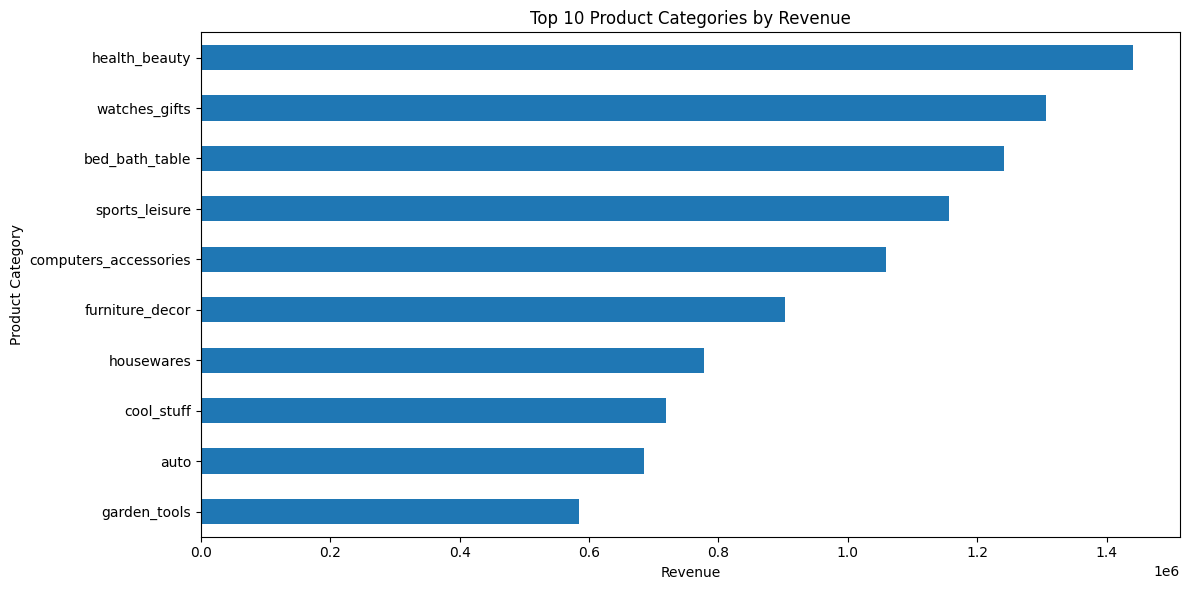

In [29]:
plt.figure(figsize=(12, 6))

category_revenue.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

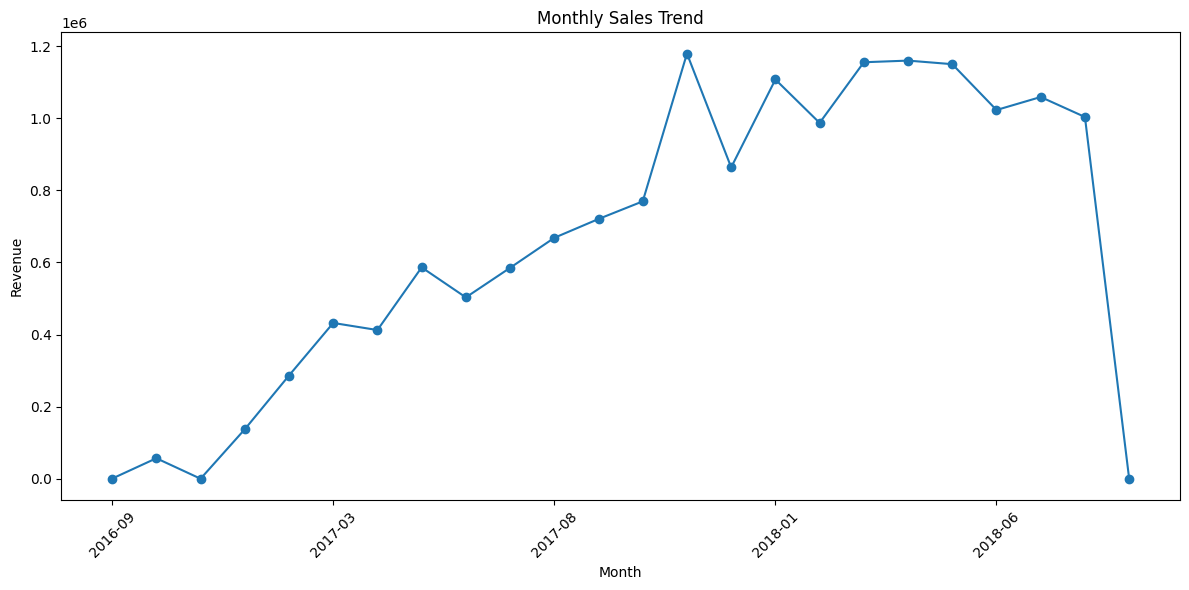

In [30]:
plt.figure(figsize=(12, 6))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

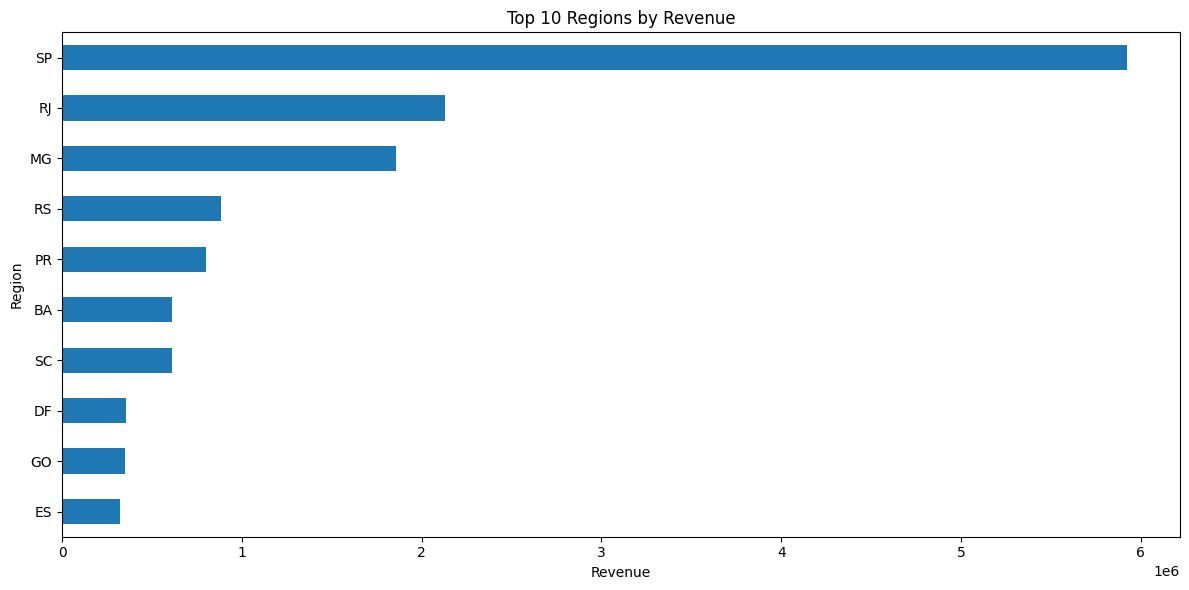

In [31]:
plt.figure(figsize=(12, 6))

regional_sales.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Regions by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

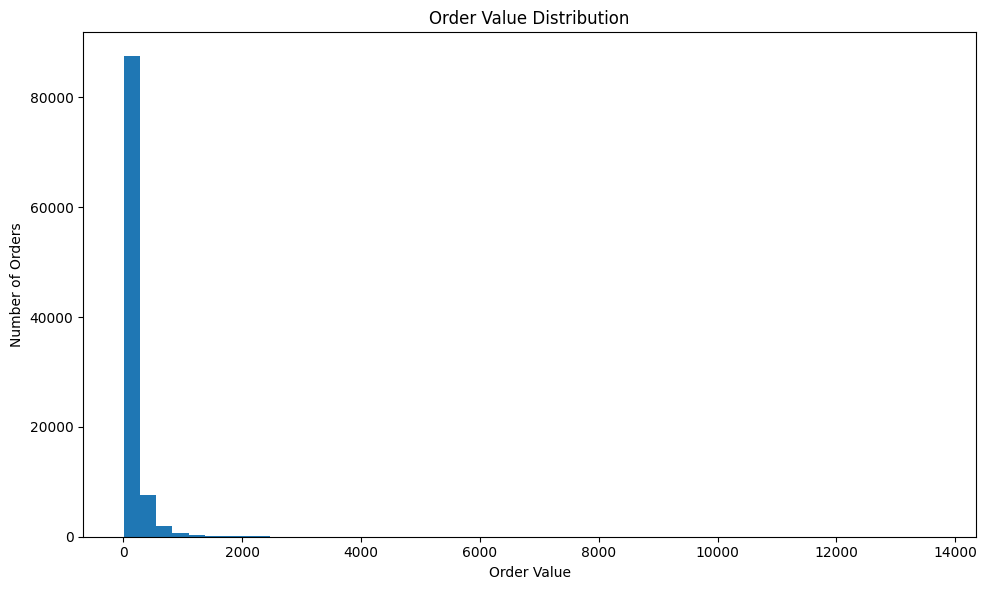

In [32]:
order_values = (
    sales.groupby("order_id")["revenue"]
    .sum()
)

plt.figure(figsize=(10, 6))

plt.hist(
    order_values,
    bins=50
)

plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

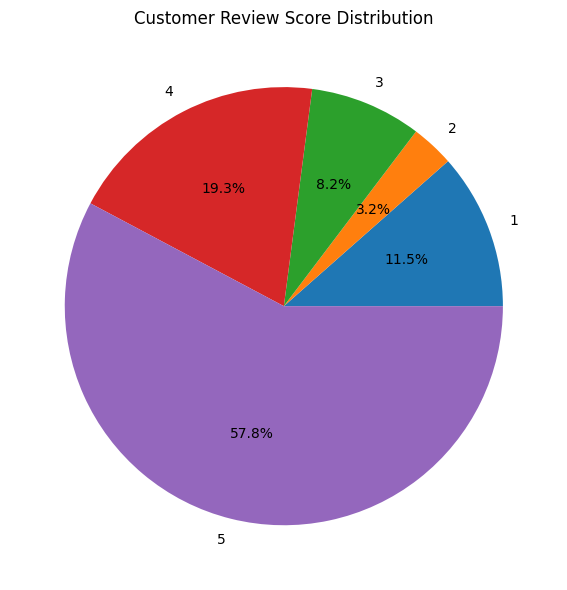

In [33]:
plt.figure(figsize=(8, 6))

review_distribution.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Review Score Distribution")
plt.ylabel("")

plt.tight_layout()
plt.show()

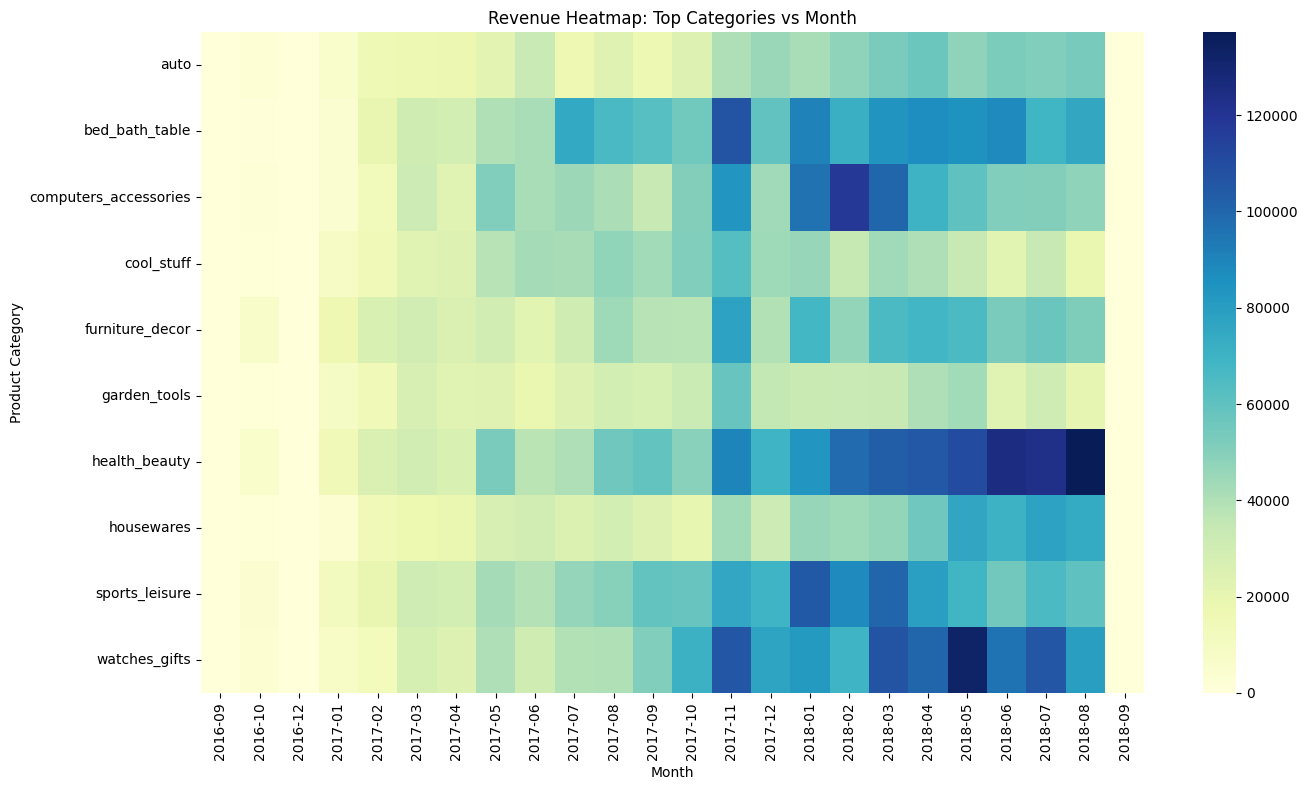

In [34]:
heatmap_data = (
    sales.pivot_table(
        index="product_category_name_english",
        columns="month",
        values="revenue",
        aggfunc="sum",
        fill_value=0
    )
)

top_categories = category_revenue.head(10).index

heatmap_data = heatmap_data.loc[
    heatmap_data.index.intersection(top_categories)
]

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Revenue Heatmap: Top Categories vs Month")
plt.xlabel("Month")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()